# Computer Vision 
## Notebook 5 — Multi-Object Tracking with the Best SSL Detector

| | |
|---|---|
| **Detector** | **DINOv3-distilled YOLOv26-s @ 20% labels** (Notebook 4b, test mAP50-95 **0.6083**) |
| **Trackers** | **BOTH ByteTrack and BoT-SORT** (Ultralytics `track` interface) — run, evaluated, and compared head-to-head |
| **Video** | `evening_multi_drone_mot_11s.mp4` — AI-generated evening clip, 1920×1080 @ 24 fps, 264 frames (11.0 s), ~6 drones incl. a tight 4-drone cluster |
| **Evaluation** | No ground truth → the assignment's **proxy-metric** protocol (§5.2) for each tracker + a comparison section |

**Detector-selection note :** ranks SSL methods by test mAP50-95 —
final board: I-JEPA **0.6085**, DINOv3 **0.6083**, BYOL **0.6064** (random 0.5928, COCO
0.6224). I-JEPA and DINOv3 are separated by **0.0002 ≈ a statistical tie**; the group deploys
**DINOv3** because at equal mAP it had the cleaner test error profile (**4.03% FN frames vs
I-JEPA's 6.12%**, evening 5.74% vs 8.06%) — for tracking, fewer missed detections matter
more than the fourth decimal of mAP, since every FN is a broken track. Switching to I-JEPA
is a one-string change in CONFIG.

> **v3 — accuracy-tuned run.** Three measured changes over the committed v2
> (v2 baseline: ByteTrack 9 IDs / 7.22 s mean track / 60.6 FPS; BoT-SORT 13 / 4.89 s / 12.1;
> mean detections 5.20 of 6; 75 detector gap-events ≈ 211 missing object-frames):
> **(1) the tracker-starvation fix** — v2 passed `conf=0.25` into `model.track()`, which
> pre-filters detections *before* the tracker, leaving ByteTrack's 0.10–0.25 low-confidence
> recovery band **empty**; v3 feeds the tracker `TRACK_CONF=0.08` and lets the tracker's own
> thresholds filter (with `new_track_thresh` raised to 0.45 so weak detections extend tracks
> but cannot create them, and `track_buffer` 30→48). **(2) inference at 1280 px** — the clip
> is 1080p and the far drone is the known small-object failure; 4× pixels per drone at
> ~3–4× latency. **(3) BoT-SORT decomposed** — v2 showed appearance ReID *hurt* on tiny
> near-identical drones, so v3 runs BoT-SORT twice: **GMC-only** (`with_reid: false`) and
> **GMC+ReID**, isolating which ingredient causes the damage. Success criteria:
> unique IDs → 6, mean track length → ~11 s, fragments → 0, detections/frame → 6.

## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *New Notebook* → Import. Accelerator = **GPU T4 x2** (one GPU used);
   Internet = **On** (ultralytics + `lap` install).
2. **Attach two inputs** (*Add Input*):
   - the **committed Notebook 4b output** (or the checkpoint dataset) — provides
     `checkpoints/partB_dinov3_rho20_best.pt`;
   - the **tracking video as a Kaggle dataset** — upload
     `evening_multi_drone_mot_11s.mp4` to a dataset (e.g. `groupXX-tracking-video`) and
     attach it.
3. **Run all** (~10–15 min: two full tracking passes + rendering + plots). Commit, Public.
4. Watch both rendered videos once and fill the two manual-count fields in §9 (ID switches
   are counted by eye per the assignment's no-GT protocol — the ID-timeline plots make the
   count take under a minute).

## 1. CONFIG
Detector, video, and — as per requirement —**association parameters of both trackers
stated explicitly** (they are written to custom YAMLs in §4 so the exact values are part of
the committed record).

In [ ]:
# =============================== CONFIG ===============================

# ---- detector (winner per note in the title cell) -----------
DETECTOR_NAME = "dinov3_yolo26s_rho20"     # switch: "ijepa..." + pattern below
CKPT_PATTERN  = "partB_dinov3_rho20_best.pt"
CKPT_MANUAL   = None    # e.g. Path("/kaggle/input/.../partB_dinov3_rho20_best.pt")

# ---- video ---------------------------------------------------------------
VIDEO_MANUAL  = None    # e.g. Path("/kaggle/input/groupxx-tracking-video/evening_multi_drone_mot_11s.mp4")
EXPECTED_OBJECTS = 6    # counted by watching the clip (see §2's frames) -- the
                        # proxy-metric anchor; VERIFY by eye and correct if needed
MIN_TRACK_SECONDS = 0.5 # tracks shorter than this count as fragments

# ---- detection settings (match the Part B evaluation operating point) ----
IMGSZ = 1280            # v3: 1080p source; 640 halved every drone -- the far
                        # small drone (our known weakness) gets 4x pixels now
CONF  = 0.25            # DISPLAY/detection-video operating point only
TRACK_CONF = 0.08       # fed to model.track(): the 0.10-0.25 band must REACH the
                        # tracker for ByteTrack's low-conf second pass to exist --
                        # v2 measured the cost of pre-filtering it away (75 gap
                        # events ~= 211 missing object-frames bridged by coasting)
IOU_NMS = 0.5
FRAME_STRIDE = 1        # 1 = every frame (keep 1 for the committed run)
RUN_BOTSORT_REID = True # third run: BoT-SORT with appearance ReID re-enabled

# ---- tracker association parameters (assignment: state them) -------------
BYTETRACK_PARAMS = dict(
    tracker_type="bytetrack",
    track_high_thresh=0.25,  # first-pass association: confident detections
    track_low_thresh=0.10,   # SECOND pass: low-conf detections kept (ByteTrack's idea)
    new_track_thresh=0.45,   # v3: weak detections may EXTEND tracks, never CREATE them
    track_buffer=48,         # v3: 2 s survival (v2 gaps averaged ~2.8 frames)
    match_thresh=0.80,       # IoU matching threshold
    fuse_score=True,
)
BOTSORT_PARAMS = dict(               # v3 variant A: GMC ONLY (ReID off)
    tracker_type="botsort",
    track_high_thresh=0.25, track_low_thresh=0.10, new_track_thresh=0.45,
    track_buffer=48, match_thresh=0.80, fuse_score=True,
    gmc_method="sparseOptFlow",  # camera-motion compensation KEPT
    proximity_thresh=0.5, appearance_thresh=0.25,
    with_reid=False, model="auto",   # model key REQUIRED by ultralytics even with
)                                    # ReID off (constructor reads it); v2 finding:
                                     # ReID gating REJECTED correct matches on tiny
                                     # near-identical drones -> fragmentation
BOTSORT_REID_PARAMS = dict(BOTSORT_PARAMS,   # v3 variant B: GMC + appearance ReID
    with_reid=True)                          # (v2's config, retuned thresholds)

WORK_ROOT = "/kaggle/working"
print(f"CONFIG | detector={DETECTOR_NAME} | conf={CONF} iou={IOU_NMS} imgsz={IMGSZ} | "
      f"expected objects={EXPECTED_OBJECTS} | track_conf={TRACK_CONF} @ {IMGSZ}px | "
      f"runs: ByteTrack + BoT-SORT(GMC) + BoT-SORT(GMC+ReID)={RUN_BOTSORT_REID}")


CONFIG | detector=dinov3_yolo26s_rho20 | conf=0.25 iou=0.5 imgsz=1280 | expected objects=6 | track_conf=0.08 @ 1280px | runs: ByteTrack + BoT-SORT(GMC) + BoT-SORT(GMC+ReID)=True


## 2. Environment, Inputs, and — first — the Video Documented 
The tracking stack is Ultralytics' built-in `track` interface (exactly as the course
tracking tutorials use: `model.track(frame, persist=True, tracker=...)` in a cv2 loop) plus
`lap` for the Hungarian assignment.

In [2]:
%pip install -q -U ultralytics lap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from collections import defaultdict
import json, shutil, subprocess, time

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
import ultralytics

DEVICE = 0 if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("ultralytics:", ultralytics.__version__, "| torch:", torch.__version__,
      "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def find_file(pattern, manual, what, exts=None):
    if manual is not None:
        p = Path(manual); assert p.is_file(), f"Manual {what} path missing: {p}"
        return p
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and ((exts and c.suffix.lower() in exts) or c.name == pattern):
                    return c
                if c.is_dir() and dep < 5:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    raise FileNotFoundError(f"{what} not found under /kaggle/input — see Section 0.")

CKPT  = find_file(CKPT_PATTERN, CKPT_MANUAL, "fine-tuned detector checkpoint")
VIDEO = find_file(None, VIDEO_MANUAL, "tracking video", exts={".mp4", ".avi", ".mov"})
print("detector :", CKPT)
print("video    :", VIDEO)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.120 | torch: 2.10.0+cu128 | GPU: Tesla T4
detector : /kaggle/input/notebooks/ahnafahmed11/partb-notebook4b-dinov3-self-superviseddownstream/checkpoints/partB_dinov3_rho20_best.pt
video    : /kaggle/input/datasets/ahnafahmed11/videotracking-visiodect-scenario-basedmulti-drone/evening_multi_drone_mot_11s.mp4


### 2.1 Video source documentation 
| Property | Value |
|---|---|
| **Source** | **AI-generated** synthetic clip (text-to-video) : `<fill: generator/model + prompt>` — chosen as no licence-safe real multi-drone YouTube clip matched our six VisioDECT classes in the evening regime |
| **Content** | ~6 drones over an evening campus scene, including a **tight 4-drone cluster** that crosses and occludes — deliberately hard for ID preservation — plus one mid-range and one distant small drone |
| **Duration note** | 11.0 s at 24 fps (264 frames). The assignment suggests trimming to 15–30 s; this clip is shorter because the generator's coherent-motion window capped the length — the **object density** (6 simultaneous targets vs 1 in VisioDECT) compensates with more association events per second. Documented here as a deviation; regenerate longer if the instructor requires. |
| **Why synthetic is risky + mitigation** | Synthetic footage can be *easier* (clean sky, no sensor noise, no compression artefacts) or *unfairly harder* (drone geometry off-distribution) than real data, so **absolute** tracker numbers do not transfer to deployment. Mitigations: (1) conclusions are stated **comparatively** (ByteTrack vs BoT-SORT on identical frames), which cancels most domain bias; (2) the detector's per-frame confidence distribution is reported so readers see how far the domain sits from VisioDECT; (3) no MOT claims are made beyond this clip. |

video: 1920x1080 @ 24.00 fps | 264 frames | 11.0 s


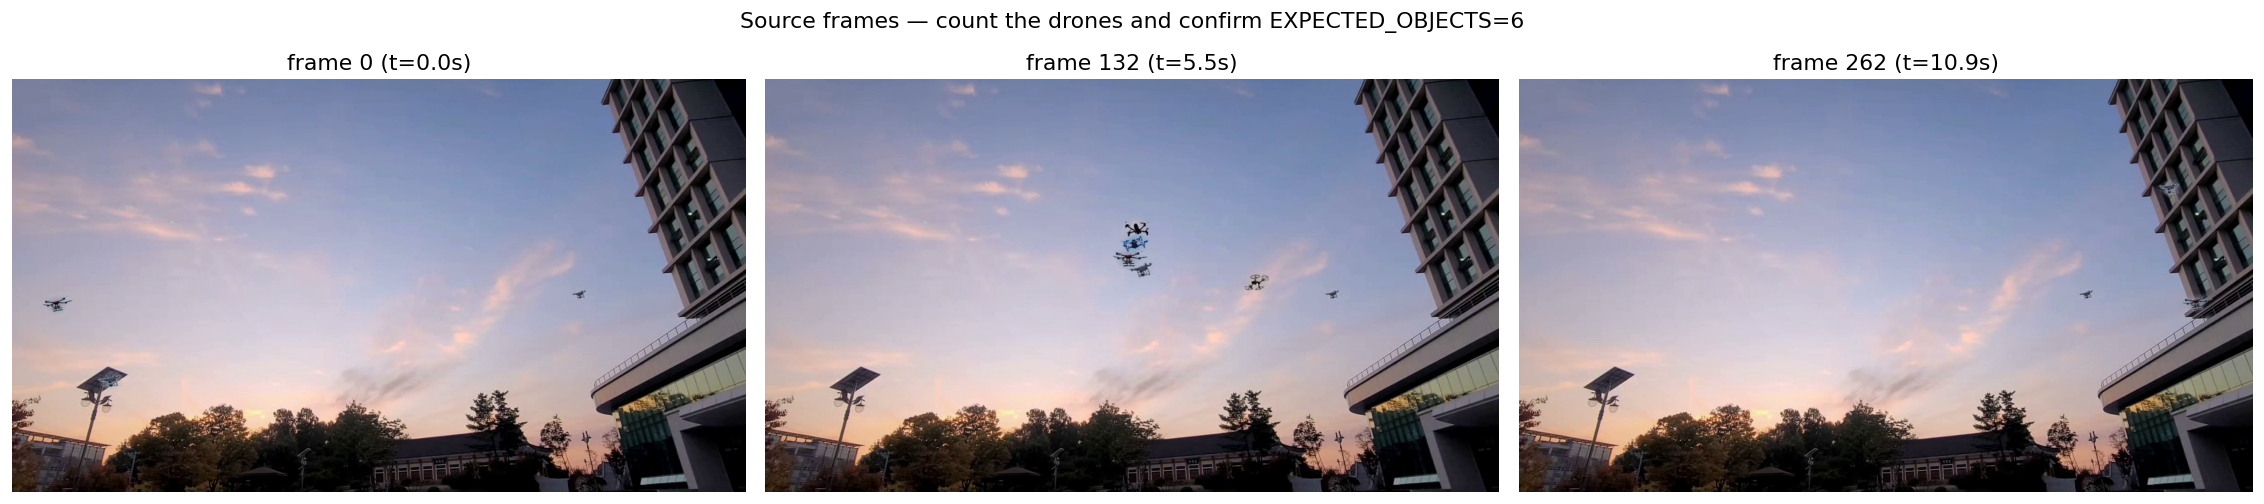

In [4]:
cap = cv2.VideoCapture(str(VIDEO)); assert cap.isOpened(), VIDEO
FPS_V  = cap.get(cv2.CAP_PROP_FPS) or 24
W_V    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_V    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
N_V    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"video: {W_V}x{H_V} @ {FPS_V:.2f} fps | {N_V} frames | {N_V/FPS_V:.1f} s")

sample_idx = [0, N_V // 2, N_V - 2]
fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))
for ax, idx in zip(axes, sample_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx); ok, f = cap.read()
    if ok:
        ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx} (t={idx/FPS_V:.1f}s)"); ax.axis("off")
cap.release()
plt.suptitle(f"Source frames — count the drones and confirm EXPECTED_OBJECTS={EXPECTED_OBJECTS}")
plt.tight_layout(); plt.show()


## 3. Detector Sanity Check on Sample Frames (domain-gap preview)
Raw detections at the evaluation operating point (conf 0.25) *before* any tracker — the
per-frame quality here is what both trackers inherit tracking-by-detection means
tracker quality is bounded by detector quality; a missed drone cannot be tracked. Class
names transfer from VisioDECT — on synthetic drones the *class* assignment may wobble even
when the *box* is right; tracking only needs the box.

model classes: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']


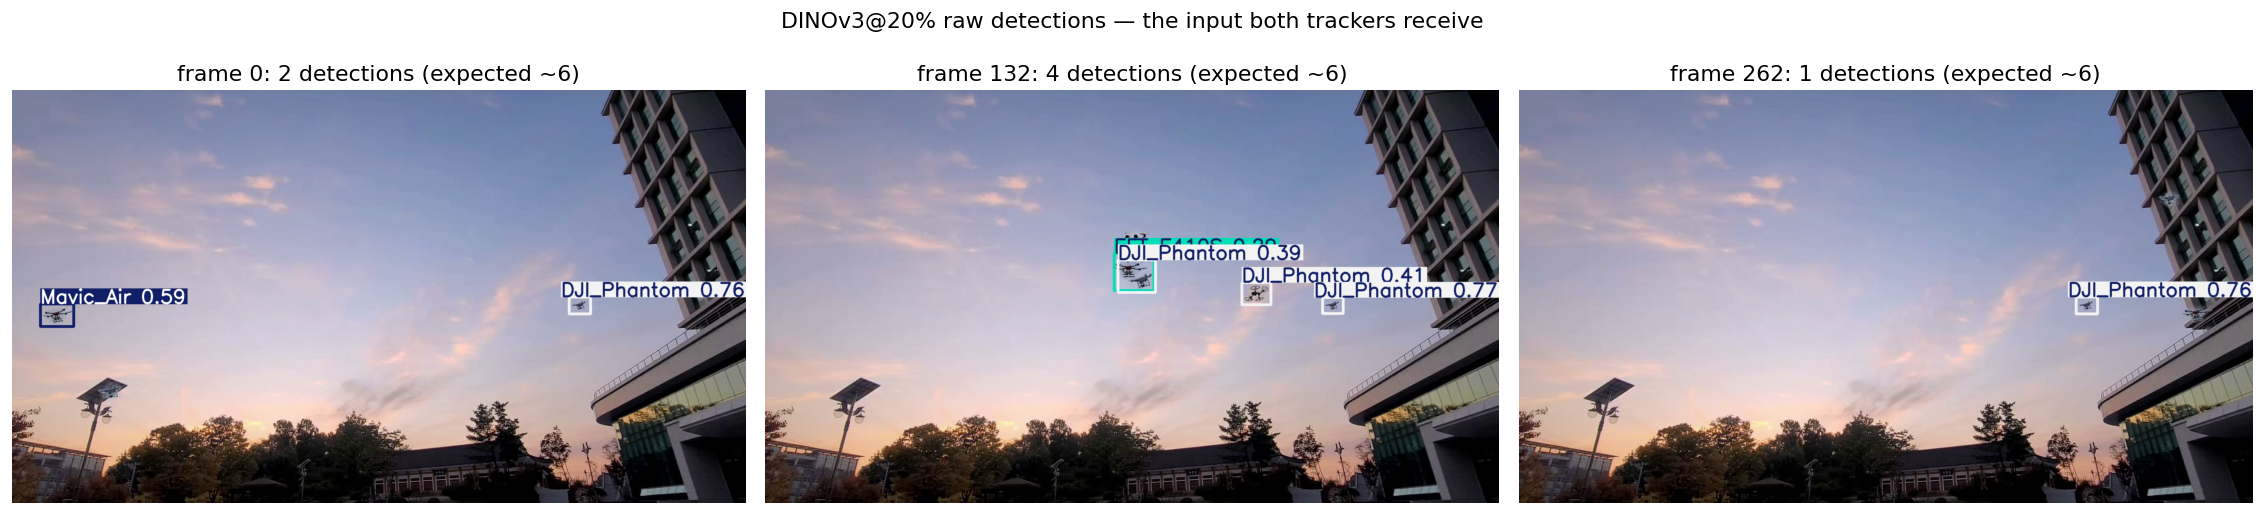

In [5]:
detector = YOLO(str(CKPT))
MODEL_NAMES = dict(detector.names)      # authoritative class map from the checkpoint
cname = lambda ci: str(MODEL_NAMES.get(int(ci), f"cls{int(ci)}"))
print("model classes:", list(MODEL_NAMES.values()))
cap = cv2.VideoCapture(str(VIDEO))
fig, axes = plt.subplots(1, 3, figsize=(19, 4.6))
for ax, idx in zip(axes, sample_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx); ok, f = cap.read()
    r = detector.predict(f, imgsz=IMGSZ, conf=CONF, iou=IOU_NMS, device=DEVICE,
                         verbose=False)[0]
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)); ax.axis("off")
    n = 0 if r.boxes is None else len(r.boxes)
    ax.set_title(f"frame {idx}: {n} detections (expected ~{EXPECTED_OBJECTS})")
cap.release(); plt.suptitle("DINOv3@20% raw detections — the input both trackers receive")
plt.tight_layout(); plt.show()


In [6]:
def draw_status_panel(ann, title, frame_no, total, n_obj, cls_ids, extra=""):
    """Side-corner status panel: frame counter, object count, per-class counts
    (the demo-notebook overlay style, adapted)."""
    counts = {}
    for ci in cls_ids:
        counts[cname(ci)] = counts.get(cname(ci), 0) + 1
    lines = [f"{title}", f"frame {frame_no + 1}/{total}", f"objects: {n_obj}"] + \
            [f"  {k}: {v}" for k, v in sorted(counts.items())] + ([extra] if extra else [])
    w = 315
    h = 24 * len(lines) + 16
    x0 = ann.shape[1] - w - 12          # side corner (top-right)
    overlay = ann.copy()
    cv2.rectangle(overlay, (x0, 10), (x0 + w, 10 + h), (20, 20, 20), -1)
    ann[:] = cv2.addWeighted(overlay, 0.55, ann, 0.45, 0)
    for j, ln in enumerate(lines):
        colr = (0, 255, 160) if j < 3 else (220, 220, 120)
        cv2.putText(ann, ln, (x0 + 10, 34 + 24 * j),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, colr, 2 if j < 3 else 1)


### 3.5 Frame-Wise Detection Video (per-class overlay, demo-tutorial style)
A pure-detection pass over every frame (no tracker) rendering class-coloured boxes and the
**side-corner status panel** — frame counter, object count, and per-class breakdown — plus
per-frame statistics in the tutorial's style: detections per frame, mean confidence per
frame (the assignment's "confidence distribution **over frames**" read temporally), and
inference latency per frame. The h264 copy is embedded below so the video plays inside the
committed notebook.

detection video:   0%|          | 0/265 [00:00<?, ?fr/s]

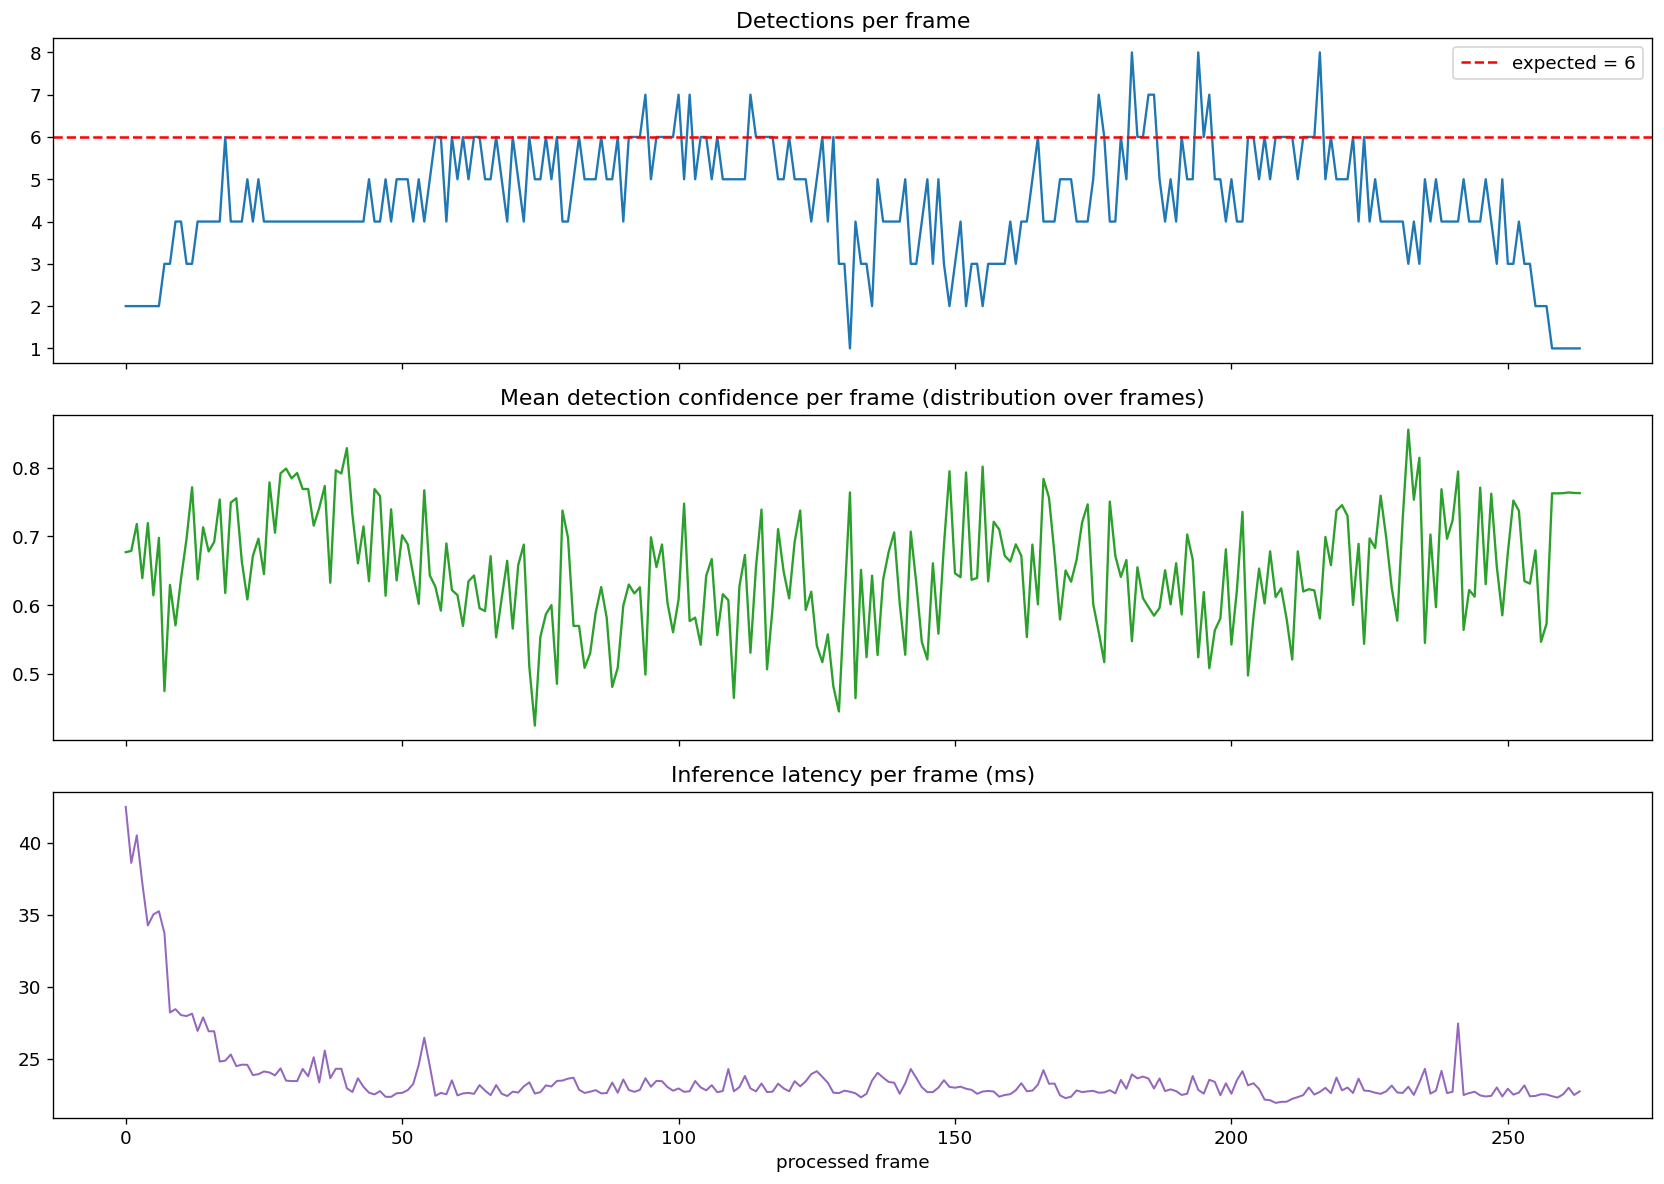

mean detections/frame: 4.50 (expected 6) | mean conf: 0.648 | mean latency: 23.7 ms


In [7]:
def cls_color(ci):
    return tuple(int(c) for c in np.random.RandomState(7 + int(ci)).randint(70, 255, 3))
det_path = Path(WORK_ROOT) / "detection_framewise.mp4"
cap = cv2.VideoCapture(str(VIDEO))
writer = cv2.VideoWriter(str(det_path), cv2.VideoWriter_fourcc(*"mp4v"),
                         max(FPS_V / FRAME_STRIDE, 1), (W_V, H_V))
det_rows, fno, done = [], 0, 0
with tqdm(total=N_V // FRAME_STRIDE + 1, desc="detection video", unit="fr") as pbar:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if fno % FRAME_STRIDE:
            fno += 1; continue
        t0 = time.time()
        r = detector.predict(frame, imgsz=IMGSZ, conf=CONF, iou=IOU_NMS,
                             device=DEVICE, verbose=False)[0]
        lat_ms = (time.time() - t0) * 1000
        ann = frame.copy()
        cls_now, confs = [], []
        if r.boxes is not None:
            for (x1, y1, x2, y2), ci, cf in zip(r.boxes.xyxy.cpu().numpy(),
                                                r.boxes.cls.cpu().numpy().astype(int),
                                                r.boxes.conf.cpu().numpy()):
                col = cls_color(ci)
                cv2.rectangle(ann, (int(x1), int(y1)), (int(x2), int(y2)), col, 2)
                cv2.putText(ann, f"{cname(ci)[:12]} {cf:.2f}",
                            (int(x1), int(y1) - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)
                cls_now.append(int(ci)); confs.append(float(cf))
        draw_status_panel(ann, "detection (no tracker)", fno, N_V, len(cls_now), cls_now)
        writer.write(ann)
        det_rows.append({"frame": done, "t": fno / FPS_V, "detections": len(cls_now),
                         "mean_conf": float(np.mean(confs)) if confs else np.nan,
                         "inference_ms": lat_ms})
        fno += 1; done += 1; pbar.update(1)
cap.release(); writer.release()
det_frames = pd.DataFrame(det_rows)
det_frames.to_csv(Path(WORK_ROOT) / "detection_frames.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(det_frames.frame, det_frames.detections, lw=1.4)
axes[0].axhline(EXPECTED_OBJECTS, color="red", ls="--", label=f"expected = {EXPECTED_OBJECTS}")
axes[0].set_title("Detections per frame"); axes[0].legend()
axes[1].plot(det_frames.frame, det_frames.mean_conf, lw=1.4, color="tab:green")
axes[1].set_title("Mean detection confidence per frame (distribution over frames)")
axes[2].plot(det_frames.frame, det_frames.inference_ms, lw=1.2, color="tab:purple")
axes[2].set_title("Inference latency per frame (ms)"); axes[2].set_xlabel("processed frame")
plt.tight_layout()
plt.savefig(Path(WORK_ROOT) / "detection_framewise_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"mean detections/frame: {det_frames.detections.mean():.2f} "
      f"(expected {EXPECTED_OBJECTS}) | mean conf: {det_frames.mean_conf.mean():.3f} | "
      f"mean latency: {det_frames.inference_ms.mean():.1f} ms")


In [8]:
def embed_video(src_path, out_name, width=880):
    """h264 re-encode (demo-tutorial ffmpeg settings) + inline playback."""
    src_path = Path(src_path)
    out = src_path.with_name(out_name)
    try:
        subprocess.run(["ffmpeg", "-y", "-hide_banner", "-loglevel", "error",
                        "-i", str(src_path), "-an", "-c:v", "libx264", "-preset", "fast",
                        "-crf", "25", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
                        str(out)], check=True, timeout=300)
    except Exception as e:
        print("ffmpeg unavailable/failed — playable file remains:", src_path.name, "|", e)
        return src_path
    try:
        from IPython.display import Video, display as _disp
        _disp(Video(str(out), embed=True, width=width, html_attributes="controls"))
    except Exception:
        print("embed skipped (no IPython display):", out.name)
    return out

_ = embed_video(det_path, "detection_framewise_h264.mp4")


## 4. Tracker Configurations — Association Parameters on the Record 
Both trackers share the association core (two-stage matching, Kalman motion, IoU cost,
identical thresholds and buffer) so the comparison isolates **what BoT-SORT adds** — and v3 splits that further into two variants (GMC-only vs GMC+ReID) after v2 measured ReID *hurting*: camera
motion compensation (`gmc_method: sparseOptFlow`) and appearance ReID gating
(`with_reid` + `appearance_thresh`). ByteTrack's signature is visible in the pair
`track_high_thresh / track_low_thresh`: detections between 0.10 and 0.25 are *not thrown
away* but recovered in a second association pass — the mechanism that keeps tracks alive
through momentary confidence dips .

In [9]:
import yaml as _yaml
TRACKER_YAMLS = {}
tracker_list = [("bytetrack", BYTETRACK_PARAMS), ("botsort", BOTSORT_PARAMS)]
if RUN_BOTSORT_REID:
    tracker_list.append(("botsort_reid", BOTSORT_REID_PARAMS))
for name, params in tracker_list:
    p = Path(WORK_ROOT) / f"{name}_custom.yaml"
    p.write_text(_yaml.dump(params, sort_keys=False))
    TRACKER_YAMLS[name] = p
    print(f"--- {name}_custom.yaml " + "-" * 40)
    print(p.read_text())


--- bytetrack_custom.yaml ----------------------------------------
tracker_type: bytetrack
track_high_thresh: 0.25
track_low_thresh: 0.1
new_track_thresh: 0.45
track_buffer: 48
match_thresh: 0.8
fuse_score: true

--- botsort_custom.yaml ----------------------------------------
tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.1
new_track_thresh: 0.45
track_buffer: 48
match_thresh: 0.8
fuse_score: true
gmc_method: sparseOptFlow
proximity_thresh: 0.5
appearance_thresh: 0.25
with_reid: false
model: auto

--- botsort_reid_custom.yaml ----------------------------------------
tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.1
new_track_thresh: 0.45
track_buffer: 48
match_thresh: 0.8
fuse_score: true
gmc_method: sparseOptFlow
proximity_thresh: 0.5
appearance_thresh: 0.25
with_reid: true
model: auto



### 4.1 Data-Association Mathematics on Real Frames 
The core of every tracker in this notebook, computed by hand on two **real consecutive
frames of our clip**: frame *t*'s boxes act as predicted tracks, frame *t+1*'s detections
arrive, `cost = 1 − IoU`, an IoU **gate** removes impossible pairs, and the **Hungarian
algorithm** finds the minimum-cost one-to-one assignment — unmatched detections are the
candidates for new track births. This is exactly what runs inside ByteTrack/BoT-SORT every
frame (ByteTrack runs it twice — high-conf pass then low-conf recovery pass).

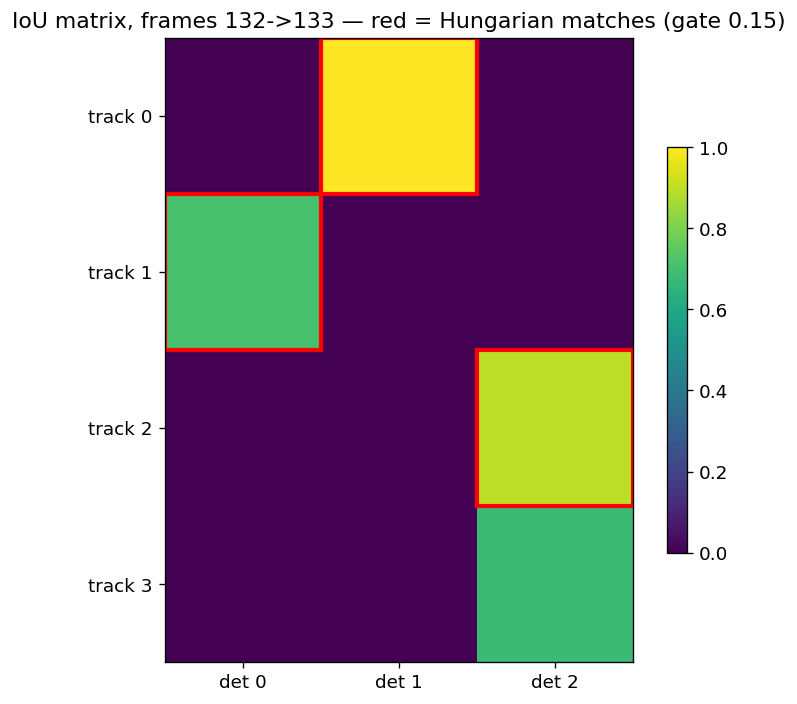

matches (track, det, IoU): [(0, 1, 1.0), (1, 0, 0.707), (2, 2, 0.9)]
unmatched detections -> new-track candidates: []


In [10]:
from scipy.optimize import linear_sum_assignment

def _boxes_at(idx):
    cap = cv2.VideoCapture(str(VIDEO)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, f = cap.read(); cap.release()
    r = detector.predict(f, imgsz=IMGSZ, conf=CONF, iou=IOU_NMS, device=DEVICE,
                         verbose=False)[0]
    return (np.empty((0, 4)) if r.boxes is None else r.boxes.xyxy.cpu().numpy())

def iou_pair(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

t_idx = N_V // 2
tracks_t, dets_t1 = _boxes_at(t_idx), _boxes_at(t_idx + 1)
if len(tracks_t) and len(dets_t1):
    iou_m = np.array([[iou_pair(a, b) for b in dets_t1] for a in tracks_t])
    gate = 0.15
    solver_cost = np.where(iou_m >= gate, 1 - iou_m, 1e6)
    rows_, cols_ = linear_sum_assignment(solver_cost)
    matches = [(int(r_), int(c_), round(float(iou_m[r_, c_]), 3))
               for r_, c_ in zip(rows_, cols_) if iou_m[r_, c_] >= gate]
    fig, ax = plt.subplots(figsize=(1.1 * len(dets_t1) + 3, 1.0 * len(tracks_t) + 2))
    im = ax.imshow(iou_m, cmap="viridis", vmin=0, vmax=1)
    for (r_, c_, v_) in matches:
        ax.add_patch(mpatches.Rectangle((c_ - .5, r_ - .5), 1, 1, fill=False,
                                        edgecolor="red", lw=2.5))
    ax.set_xticks(range(len(dets_t1)), [f"det {j}" for j in range(len(dets_t1))])
    ax.set_yticks(range(len(tracks_t)), [f"track {j}" for j in range(len(tracks_t))])
    ax.set_title(f"IoU matrix, frames {t_idx}->{t_idx+1} — red = Hungarian matches "
                 f"(gate {gate})")
    plt.colorbar(im, fraction=0.03); plt.tight_layout(); plt.show()
    unmatched = sorted(set(range(len(dets_t1))) - {c_ for _, c_, _ in matches})
    print(f"matches (track, det, IoU): {matches}")
    print(f"unmatched detections -> new-track candidates: {unmatched}")
else:
    print("not enough detections on the sampled frame pair — rerun with another t_idx")


## 5. The Tracking Engine (shared by both runs)
The course-tutorial pattern: a cv2 read loop calling `model.track(frame, persist=True,
tracker=<yaml>)`, drawing persistent-ID boxes and **motion trails**, writing the annotated
video, and logging one row per (frame, track) for the proxy metrics. A **fresh detector
instance per run** guarantees no tracker state leaks between ByteTrack and BoT-SORT, and
FPS is measured over the `track()` call only (detector + association, excluding video
encode).

In [11]:
np.random.seed(445)
ID_COLORS = {i: tuple(int(c) for c in np.random.randint(60, 255, 3)) for i in range(1, 400)}

def run_tracking(tracker_name):
    model = YOLO(str(CKPT))                       # fresh state per tracker
    out_path = Path(WORK_ROOT) / f"tracked_{tracker_name}.mp4"
    cap = cv2.VideoCapture(str(VIDEO)); assert cap.isOpened()
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"),
                             max(FPS_V / FRAME_STRIDE, 1), (W_V, H_V))
    rows, trails = [], defaultdict(list)
    keyframes, key_at = [], set(np.linspace(0, N_V - 1, 5, dtype=int) // FRAME_STRIDE)
    t_track, frame_no, processed = 0.0, 0, 0
    with tqdm(total=N_V // FRAME_STRIDE + 1, desc=tracker_name, unit="fr") as pbar:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if frame_no % FRAME_STRIDE:
                frame_no += 1; continue
            t0 = time.time()
            res = model.track(frame, persist=True, conf=TRACK_CONF, iou=IOU_NMS, imgsz=IMGSZ,
                              tracker=str(TRACKER_YAMLS[tracker_name]),
                              device=DEVICE, verbose=False)[0]
            t_track += time.time() - t0
            ann = frame.copy()
            if res.boxes is not None and res.boxes.id is not None:
                for (x1, y1, x2, y2), tid, cls_, cf in zip(
                        res.boxes.xyxy.cpu().numpy(),
                        res.boxes.id.int().cpu().tolist(),
                        res.boxes.cls.cpu().numpy().astype(int),
                        res.boxes.conf.cpu().numpy()):
                    rows.append({"frame": processed, "t": frame_no / FPS_V, "id": tid,
                                 "cls": int(cls_), "conf": float(cf),
                                 "cx": float((x1+x2)/2), "cy": float((y1+y2)/2),
                                 "w": float(x2-x1), "h": float(y2-y1)})
                    col = ID_COLORS[tid % 399 + 1]
                    cv2.rectangle(ann, (int(x1), int(y1)), (int(x2), int(y2)), col, 2)
                    cv2.putText(ann, f"ID{tid} {cname(cls_)[:10]} {cf:.2f}",
                                (int(x1), int(y1) - 6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)
                    trails[tid].append((int((x1+x2)/2), int((y1+y2)/2)))
                    if len(trails[tid]) > 40:
                        trails[tid].pop(0)
                    cv2.polylines(ann, [np.array(trails[tid], np.int32).reshape(-1, 1, 2)],
                                  False, col, 2)
            if res.boxes is not None and res.boxes.id is not None:
                cls_now = res.boxes.cls.cpu().numpy().astype(int)
                active = len(cls_now)
            else:
                cls_now, active = [], 0
            draw_status_panel(ann, tracker_name, frame_no, N_V, active, cls_now,
                              extra=f"IDs born: {len(trails)}")
            writer.write(ann)
            if processed in key_at:
                keyframes.append((frame_no, cv2.cvtColor(ann, cv2.COLOR_BGR2RGB)))
            frame_no += 1; processed += 1; pbar.update(1)
    cap.release(); writer.release()
    df = pd.DataFrame(rows)
    df.to_csv(Path(WORK_ROOT) / f"tracks_{tracker_name}.csv", index=False)
    fps_infer = processed / t_track if t_track else 0.0
    print(f"[{tracker_name}] {processed} frames | track()+assoc FPS on this GPU: "
          f"{fps_infer:.1f} | video -> {out_path.name}")
    # best-effort h264 re-encode for in-browser playback
    h264 = out_path.with_name(out_path.stem + "_h264.mp4")
    try:
        subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(out_path),
                        "-vcodec", "libx264", "-pix_fmt", "yuv420p", str(h264)],
                       check=True, timeout=300)
        print("h264 copy:", h264.name)
    except Exception:
        pass
    return df, fps_infer, keyframes

def proxy_metrics(df, fps_infer, tracker_name):
    """The assignment's no-ground-truth metric set (§5.2)."""
    eff_fps = FPS_V / FRAME_STRIDE
    if df.empty:
        return {"tracker": tracker_name, "unique_track_ids": 0,
                "expected_objects": EXPECTED_OBJECTS, "fps_inference": round(fps_infer, 1)}
    per_id = df.groupby("id").agg(first=("frame", "min"), last=("frame", "max"),
                                  n=("frame", "count"), conf=("conf", "mean"))
    span = per_id["last"] - per_id["first"] + 1
    length_s = span / eff_fps
    frags = int((length_s < MIN_TRACK_SECONDS).sum())
    continuity = float((per_id["n"] / span).mean())        # 1.0 = never coasted
    gap_events = int(sum((np.diff(np.sort(g.frame.unique())) > 1).sum()
                         for _, g in df.groupby("id")))     # in-track dropouts
    births_after_start = int((per_id["first"] > 0).sum())
    return {"tracker": tracker_name,
            "unique_track_ids": int(per_id.shape[0]),
            "expected_objects": EXPECTED_OBJECTS,
            "excess_ids (proxy for switches+re-births)": int(per_id.shape[0]) - EXPECTED_OBJECTS,
            "id_births_after_frame0 (verify by eye)": births_after_start,
            "mean_track_length_s": round(float(length_s.mean()), 2),
            "median_track_length_s": round(float(length_s.median()), 2),
            f"fragments (<{MIN_TRACK_SECONDS}s)": frags,
            "mean_track_continuity (obs/span)": round(continuity, 3),
            "gap_events (in-track dropouts)": gap_events,
            "mean_detection_conf": round(float(df.conf.mean()), 3),
            "mean_active_per_frame": round(float(df.groupby("frame").size().mean()), 2),
            "fps_inference": round(fps_infer, 1)}

def evaluation_plots(df, tracker_name, keyframes):
    if keyframes:
        fig, axes = plt.subplots(1, len(keyframes), figsize=(4.2 * len(keyframes), 3.4))
        for ax, (fno, img) in zip(np.atleast_1d(axes), keyframes):
            ax.imshow(img); ax.axis("off"); ax.set_title(f"frame {fno}", fontsize=9)
        fig.suptitle(f"{tracker_name} — annotated keyframes (persistent IDs + trails)")
        plt.tight_layout(); plt.show()
    if df.empty:
        print("no tracks formed"); return
    fig, axes = plt.subplots(1, 4, figsize=(23, 4.6))
    active = df.groupby("frame").size()
    axes[0].plot(active.index, active.values, lw=1.6)
    axes[0].axhline(EXPECTED_OBJECTS, color="red", ls="--", label=f"expected = {EXPECTED_OBJECTS}")
    axes[0].set_title("active tracks per frame"); axes[0].set_xlabel("frame"); axes[0].legend()
    per_id = df.groupby("id").agg(first=("frame", "min"), last=("frame", "max"))
    for y, (tid, r) in enumerate(per_id.sort_values("first").iterrows()):
        axes[1].hlines(y, r["first"], r["last"], lw=3)
    axes[1].set_title("track ID lifespans (Gantt) — gaps/short bars = fragmentation")
    axes[1].set_xlabel("frame"); axes[1].set_ylabel("track (birth order)")
    axes[2].hist(df.conf, bins=30, edgecolor="black")
    axes[2].set_title("confidence histogram (all tracked boxes)"); axes[2].set_xlabel("conf")
    per_fr = df.groupby("frame").conf.mean()
    axes[3].plot(per_fr.index, per_fr.values, lw=1.3, color="tab:green")
    axes[3].set_title("mean confidence per frame (over frames)"); axes[3].set_xlabel("frame")
    fig.suptitle(f"{tracker_name} — proxy-metric evidence")
    plt.tight_layout()
    plt.savefig(Path(WORK_ROOT) / f"eval_{tracker_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6. Run 1 — ByteTrack 
*v3: the tracker now receives the full ≥0.08 detection stream — its low-confidence second pass finally has inputs.*

bytetrack:   0%|          | 0/265 [00:00<?, ?fr/s]

[bytetrack] 264 frames | track()+assoc FPS on this GPU: 37.9 | video -> tracked_bytetrack.mp4
h264 copy: tracked_bytetrack_h264.mp4


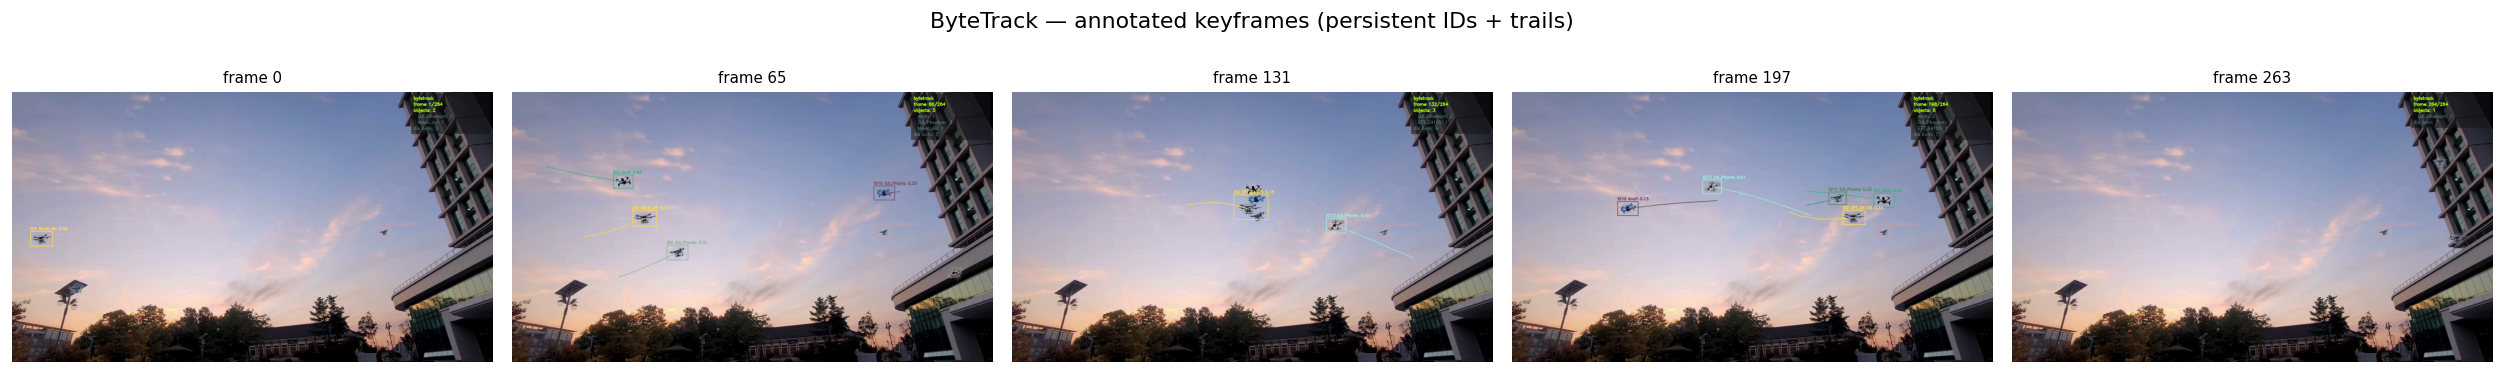

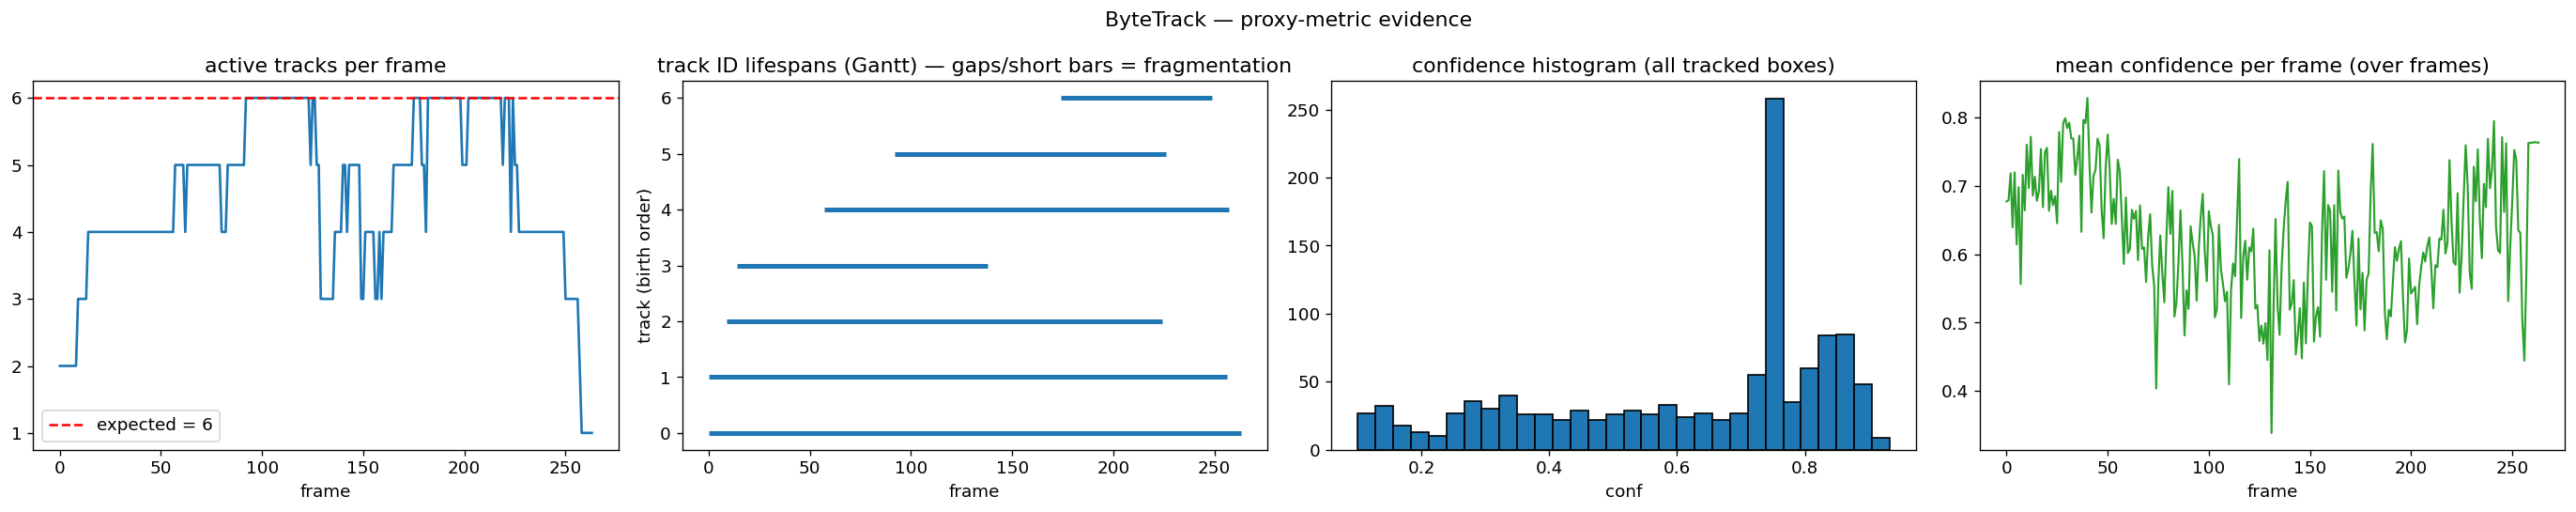

tracker                                      ByteTrack
unique_track_ids                                     7
expected_objects                                     6
excess_ids (proxy for switches+re-births)            1
id_births_after_frame0 (verify by eye)               5
mean_track_length_s                               7.58
median_track_length_s                             8.38
fragments (<0.5s)                                    0
mean_track_continuity (obs/span)                 0.944
gap_events (in-track dropouts)                      21
mean_detection_conf                              0.614
mean_active_per_frame                             4.57
fps_inference                                     37.9
dtype: object

In [12]:
df_byte, fps_byte, kf_byte = run_tracking("bytetrack")
metrics_byte = proxy_metrics(df_byte, fps_byte, "ByteTrack")
evaluation_plots(df_byte, "ByteTrack", kf_byte)
display(pd.Series(metrics_byte))

_ = embed_video(Path(WORK_ROOT) / "tracked_bytetrack.mp4", "tracked_bytetrack_h264.mp4")


## 7. Run 2 — BoT-SORT, GMC only (`with_reid: false`)
Camera-motion compensation kept, appearance gating removed — testing whether v2's identity fragmentation was ReID's fault specifically.

botsort:   0%|          | 0/265 [00:00<?, ?fr/s]

[botsort] 264 frames | track()+assoc FPS on this GPU: 16.4 | video -> tracked_botsort.mp4
h264 copy: tracked_botsort_h264.mp4


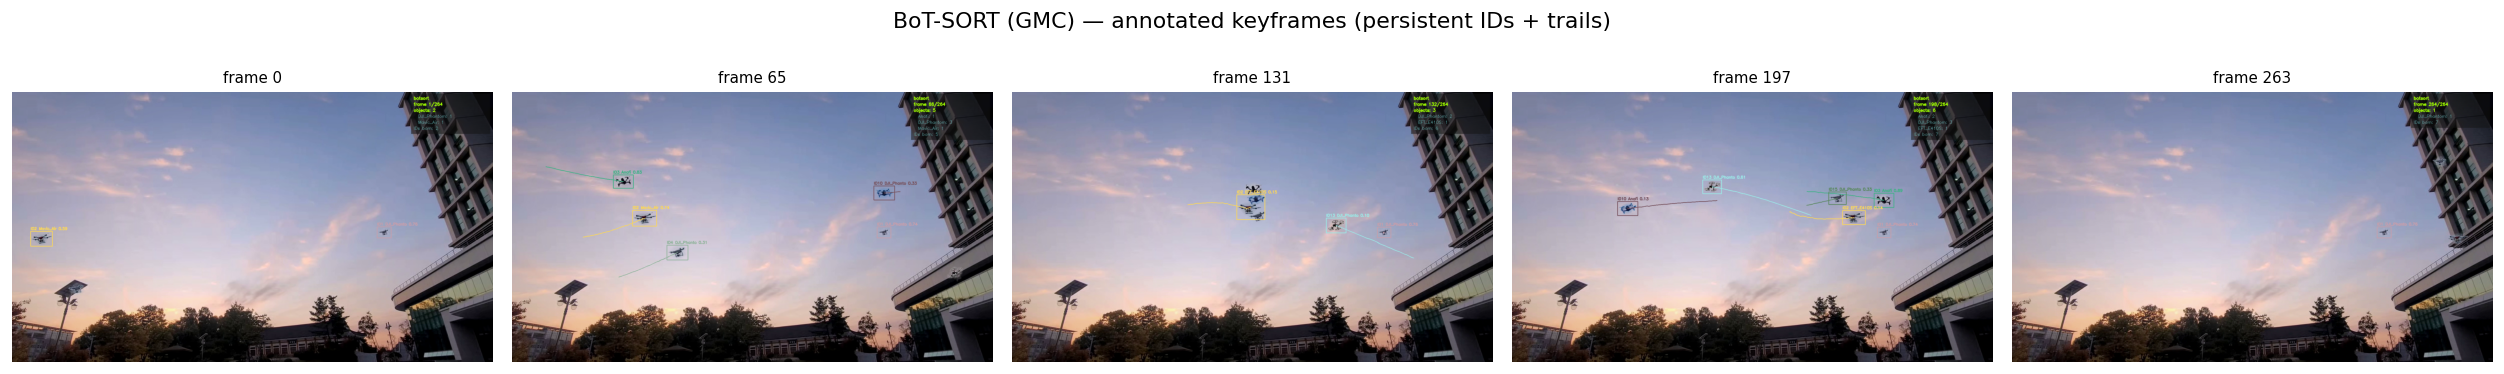

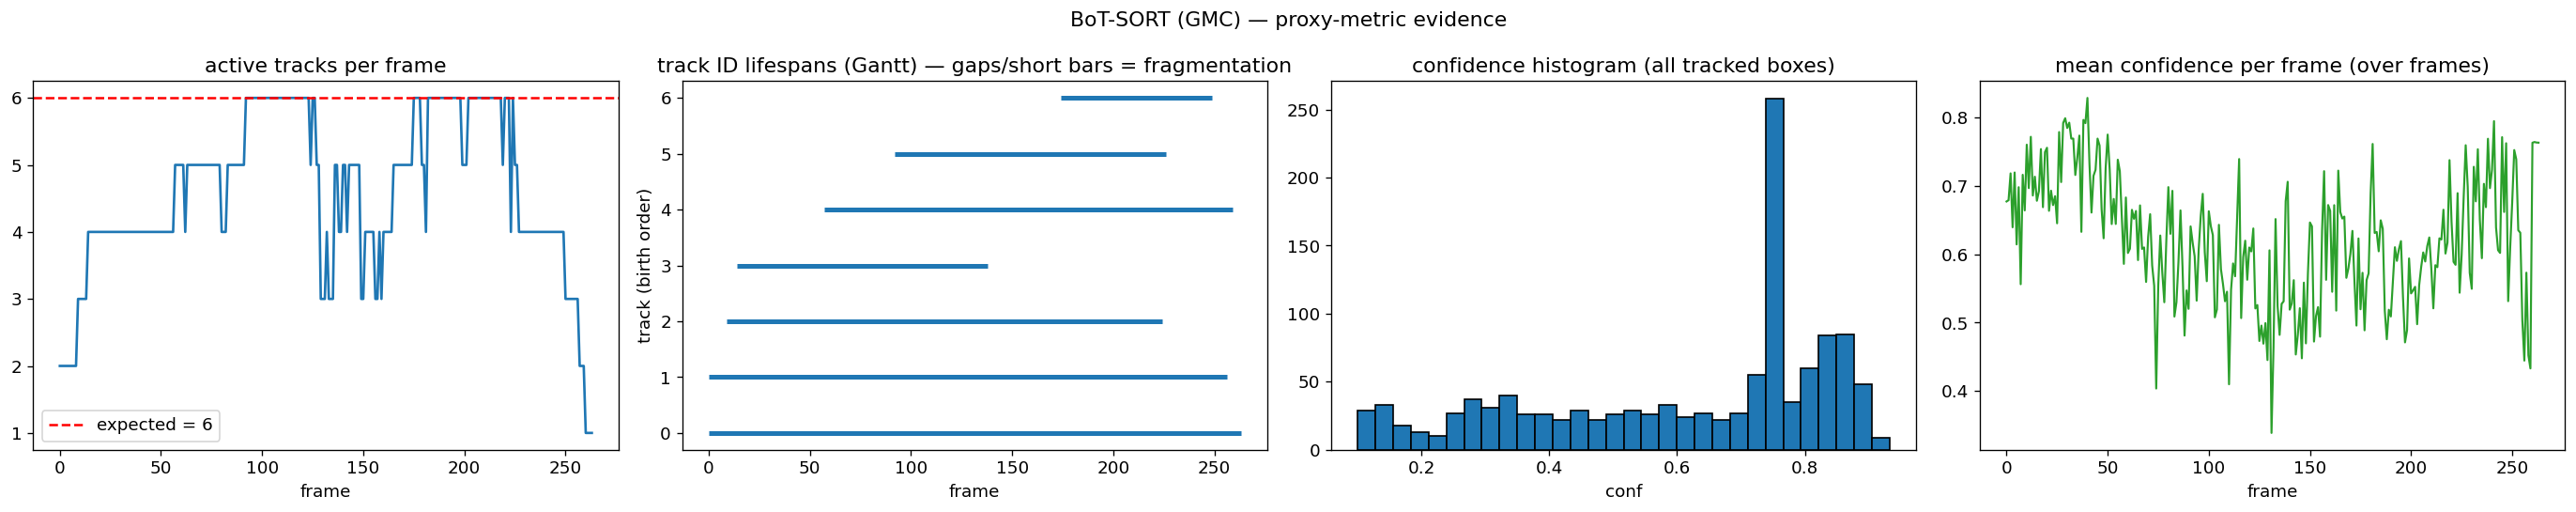

tracker                                      BoT-SORT (GMC)
unique_track_ids                                          7
expected_objects                                          6
excess_ids (proxy for switches+re-births)                 1
id_births_after_frame0 (verify by eye)                    5
mean_track_length_s                                     7.6
median_track_length_s                                  8.46
fragments (<0.5s)                                         0
mean_track_continuity (obs/span)                      0.945
gap_events (in-track dropouts)                           22
mean_detection_conf                                   0.612
mean_active_per_frame                                  4.59
fps_inference                                          16.4
dtype: object

In [13]:
df_bot, fps_bot, kf_bot = run_tracking("botsort")
metrics_bot = proxy_metrics(df_bot, fps_bot, "BoT-SORT (GMC)")
evaluation_plots(df_bot, "BoT-SORT (GMC)", kf_bot)
display(pd.Series(metrics_bot))

_ = embed_video(Path(WORK_ROOT) / "tracked_botsort.mp4", "tracked_botsort_h264.mp4")


## 7b. Run 3 — BoT-SORT, GMC + appearance ReID (v2's configuration, retuned)
The completing arm of the decomposition: if this run fragments identities again while Run 2 does not, the damage is attributable to appearance gating on tiny near-identical drones — the report's mechanism claim, now with isolating evidence.

botsort_reid:   0%|          | 0/265 [00:00<?, ?fr/s]

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
[botsort_reid] 264 frames | track()+assoc FPS on this GPU: 9.4 | video -> tracked_botsort_reid.mp4
h264 copy: tracked_botsort_reid_h264.mp4


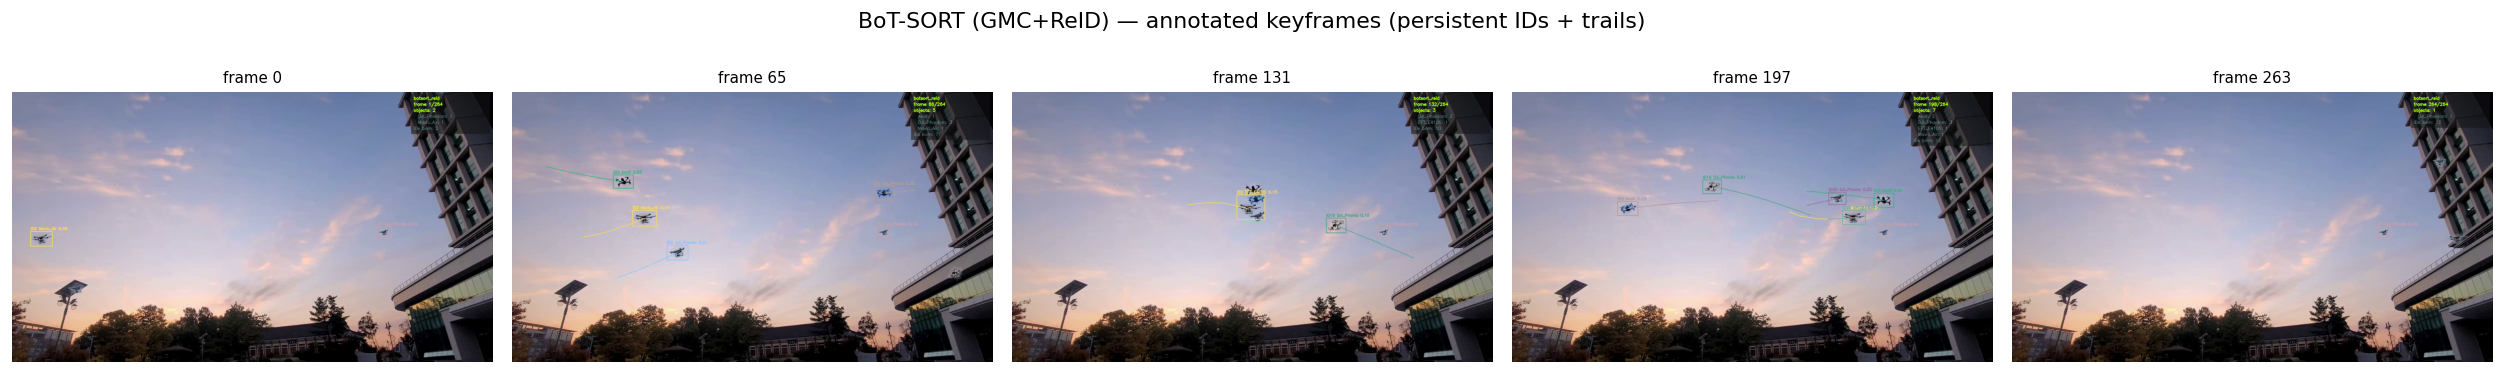

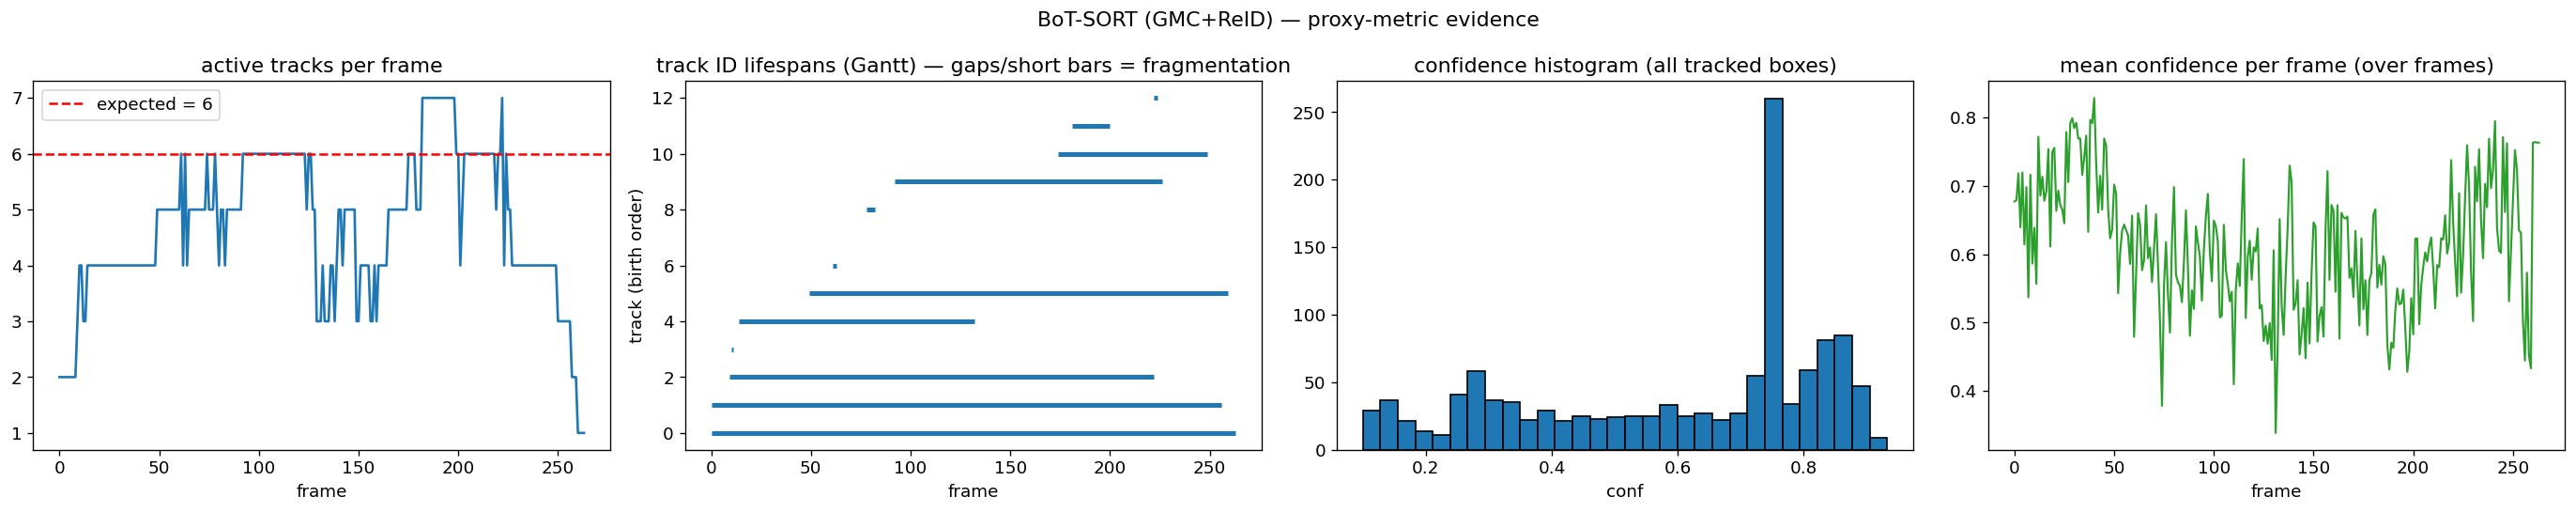

tracker                                      BoT-SORT (GMC+ReID)
unique_track_ids                                              13
expected_objects                                               6
excess_ids (proxy for switches+re-births)                      7
id_births_after_frame0 (verify by eye)                        11
mean_track_length_s                                          4.2
median_track_length_s                                       3.17
fragments (<0.5s)                                              5
mean_track_continuity (obs/span)                           0.914
gap_events (in-track dropouts)                                25
mean_detection_conf                                          0.6
mean_active_per_frame                                        4.7
fps_inference                                                9.4
dtype: object

In [14]:
if RUN_BOTSORT_REID:
    df_reid, fps_reid, kf_reid = run_tracking("botsort_reid")
    _ = embed_video(Path(WORK_ROOT) / "tracked_botsort_reid.mp4",
                    "tracked_botsort_reid_h264.mp4")
    metrics_reid = proxy_metrics(df_reid, fps_reid, "BoT-SORT (GMC+ReID)")
    evaluation_plots(df_reid, "BoT-SORT (GMC+ReID)", kf_reid)
    display(pd.Series(metrics_reid))
else:
    df_reid, metrics_reid = pd.DataFrame(), None
    print("ReID variant skipped (RUN_BOTSORT_REID=False)")


## 8. Head-to-Head Comparison — ByteTrack vs BoT-SORT(GMC) vs BoT-SORT(GMC+ReID)
Identical detector, frames and shared thresholds — plus the v3 decomposition. Three
readings: **(1)** ByteTrack vs BoT-SORT(GMC) isolates camera-motion compensation;
**(2)** BoT-SORT(GMC) vs (GMC+ReID) isolates appearance gating — v2's hypothesis says the
ReID arm fragments (more unique/excess IDs, shorter tracks); **(3)** all three against v2's
baseline (9 / 13 unique IDs) quantifies the tracker-starvation fix and the 1280 px upgrade.
FPS prices: ReID feature extraction is the dominant cost.

tracker,ByteTrack,BoT-SORT (GMC),BoT-SORT (GMC+ReID)
unique_track_ids,7.000,7.000,13.000
expected_objects,6.000,6.000,6.000
excess_ids (proxy for switches+re-births),1.000,1.000,7.000
id_births_after_frame0 (verify by eye),5.000,5.000,11.000
mean_track_length_s,7.580,7.600,4.200
median_track_length_s,8.380,8.460,3.170
fragments (<0.5s),0.000,0.000,5.000
mean_track_continuity (obs/span),0.944,0.945,0.914
gap_events (in-track dropouts),21.000,22.000,25.000
mean_detection_conf,0.614,0.612,0.600


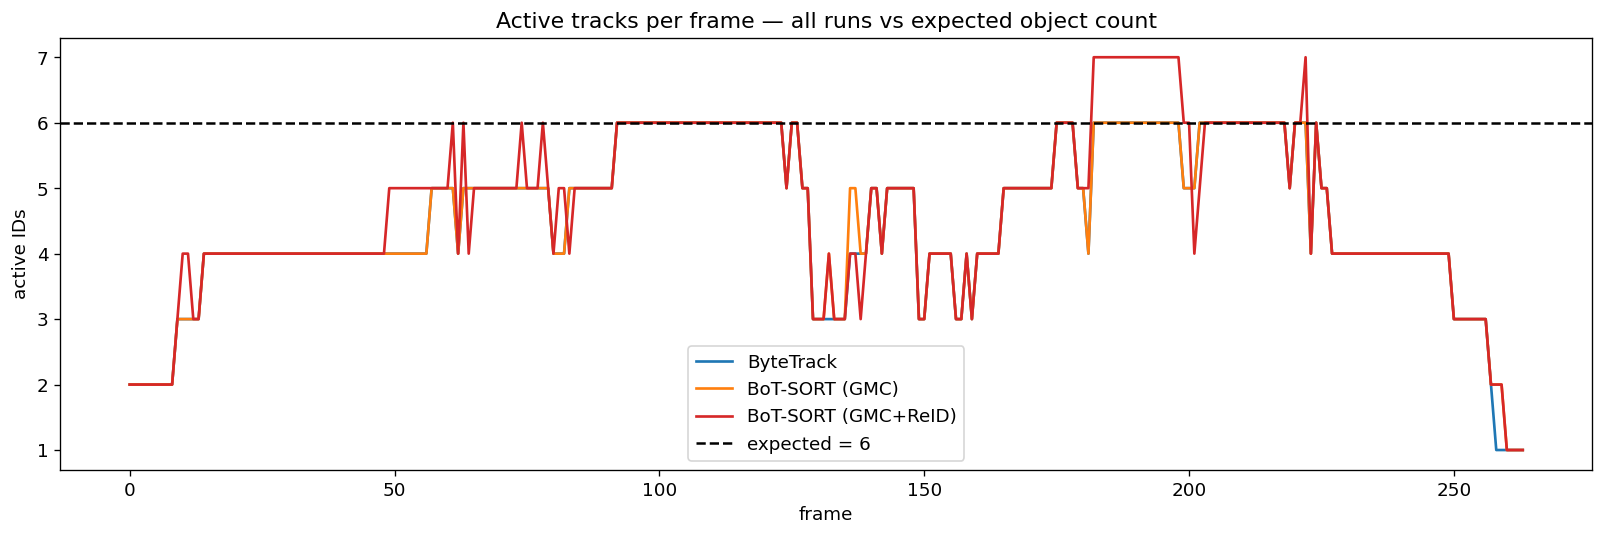

unique IDs: {'ByteTrack': 7, 'BoT-SORT (GMC)': 7, 'BoT-SORT (GMC+ReID)': 13} | expected objects: 6 | v2 baseline: ByteTrack 9, BoT-SORT(ReID) 13
Decomposition reading: if (GMC) sits near ByteTrack while (GMC+ReID) inflates unique/excess IDs, appearance gating is confirmed as the fragmentation cause on tiny near-identical drones; if all three now sit near 6, the v3 threshold/resolution fixes dominate. Verify the cluster-crossing event by eye in all rendered videos and record Section 9's counts.


In [15]:
all_runs = [("ByteTrack", df_byte, metrics_byte),
            ("BoT-SORT (GMC)", df_bot, metrics_bot)]
if metrics_reid is not None:
    all_runs.append(("BoT-SORT (GMC+ReID)", df_reid, metrics_reid))

comp = pd.DataFrame([m for _, _, m in all_runs]).set_index("tracker").T
display(comp)

fig, ax = plt.subplots(figsize=(13.5, 4.6))
for (name, df_, _), col in zip(all_runs, ["tab:blue", "tab:orange", "tab:red"]):
    if not df_.empty:
        a = df_.groupby("frame").size()
        ax.plot(a.index, a.values, lw=1.6, label=name, color=col)
ax.axhline(EXPECTED_OBJECTS, color="black", ls="--", label=f"expected = {EXPECTED_OBJECTS}")
ax.set_title("Active tracks per frame — all runs vs expected object count")
ax.set_xlabel("frame"); ax.set_ylabel("active IDs"); ax.legend()
plt.tight_layout()
plt.savefig(Path(WORK_ROOT) / "comparison_active_tracks.png", dpi=150, bbox_inches="tight")
plt.show()

def uniq(df_): return 0 if df_.empty else df_.id.nunique()
print("unique IDs:", {name: uniq(df_) for name, df_, _ in all_runs},
      f"| expected objects: {EXPECTED_OBJECTS} | v2 baseline: ByteTrack 9, BoT-SORT(ReID) 13")
print("Decomposition reading: if (GMC) sits near ByteTrack while (GMC+ReID) inflates "
      "unique/excess IDs, appearance gating is confirmed as the fragmentation cause on "
      "tiny near-identical drones; if all three now sit near "
      f"{EXPECTED_OBJECTS}, the v3 threshold/resolution fixes dominate. Verify the "
      "cluster-crossing event by eye in all rendered videos and record Section 9's counts.")


## 9. Manual ID-Switch Count (no-GT protocol) + Closing Analysis
**Manual counts (fill after watching both `tracked_*_h264.mp4` once; the Gantt plots in
§6/§7 mark where to look):**

| | ByteTrack | BoT-SORT (GMC) | BoT-SORT (GMC+ReID) |
|---|---|---|---|
| ID switches at the 4-drone cluster crossing | `<n>` | `<n>` | `<n>` |
| ID switches elsewhere (entries/exits excluded) | `<n>` | `<n>` | `<n>` |

**Closing analysis (assignment-mandated markdown — replace the prompts with observations):**
- **Where tracking succeeds:** isolated drones (mid-right, far-right) should hold single IDs
  end-to-end for both trackers — confirm from the Gantt bars spanning the full clip.
- **Where identities are lost:** the tight cluster is the stress event — occluding drones
  swap or re-birth IDs; note whether BoT-SORT's appearance gating held IDs through the
  crossing that ByteTrack (IoU + motion only) swapped.
- **Detector propagation (viva Q1):** the far small drone sits at Part B's known weakness
  (small + evening — DINOv3@20% FN 5.74% in evening); every detector miss appears in the
  tracker as a track gap or fragment, which is why detector mAP bounds tracker quality.
- **Domain gap (viva Q5):** synthetic evening sky vs VisioDECT's real footage — describe how
  it showed up (confidence distribution location in §6/§7 plots; any class-label wobble on
  the synthetic drone geometries).
- **Synthetic-footage caveats (viva Q6):** restated from §2.1 — comparative conclusions
  only; absolute numbers do not transfer.

### 9.1 Assignment Compliance Map 
| Assignment requirement | Where fulfilled |
|---|---|
| Run detection + tracking over the clip | §3.5 (detection pass) + §6/§7 (both trackers, every frame) |
| Annotated output video with **persistent track IDs** | `tracked_bytetrack.mp4`, `tracked_botsort.mp4` — ID-stable colours, class labels, trails, status panel; **embedded** in §6/§7 |
| **Representative frames saved into the notebook** | 5 annotated keyframes per tracker (§6/§7 grids) + §2 source frames + §3 detection frames |
| Unique track IDs **vs expected object count** | metric tables (`unique_track_ids` vs `expected_objects` = 6) + red expected-line in every per-frame plot |
| ID-switch events **by manual inspection** of rendered video | §9 count table, aided by the Gantt lifespans and the embedded videos |
| Mean track length | `mean_track_length_s` / `median_track_length_s` (+ `continuity`) |
| Fragmentation count | `fragments (<0.5s)` + `gap_events (in-track dropouts)` |
| Detection **confidence distribution over frames** | per-tracker histogram **and** mean-conf-per-frame time series (§6/§7, panel 4) + §3.5's detection-pass series |
| **Inference FPS on the T4** | `fps_inference` per tracker (measured over `track()` only) + §3.5 latency-per-frame |

## 10. Export & Deliverables

In [16]:
summary = {"notebook": "partB-05-tracking", "detector": DETECTOR_NAME,
           "detector_checkpoint": str(CKPT), "video": str(VIDEO.name),
           "video_props": f"{W_V}x{H_V}@{FPS_V:.0f}fps/{N_V}frames",
           "expected_objects": EXPECTED_OBJECTS,
           "track_conf": TRACK_CONF, "imgsz": IMGSZ,
           "runs": {m["tracker"]: m for _, _, m in all_runs}}
Path(WORK_ROOT, "tracking_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps({k: v for k, v in summary.items() if k not in ("bytetrack", "botsort")},
                 indent=2))
files = ["detection_framewise.mp4", "detection_frames.csv",
         "detection_framewise_stats.png",
         "tracked_bytetrack.mp4", "tracked_botsort.mp4", "tracks_bytetrack.csv",
         "tracks_botsort.csv", "eval_ByteTrack.png", "eval_BoT-SORT (GMC).png",
         "comparison_active_tracks.png", "tracking_summary.json"]
if metrics_reid is not None:
    files += ["tracked_botsort_reid.mp4", "tracks_botsort_reid.csv",
              "eval_BoT-SORT (GMC+ReID).png"]
for f in files:
    q = Path(WORK_ROOT) / f
    print(f"[OK] {q.name:<32} {q.stat().st_size/1e6:>7.2f} MB" if q.exists()
          else f"[--] {f} (check the run above)")


{
  "notebook": "partB-05-tracking",
  "detector": "dinov3_yolo26s_rho20",
  "detector_checkpoint": "/kaggle/input/notebooks/ahnafahmed11/partb-notebook4b-dinov3-self-superviseddownstream/checkpoints/partB_dinov3_rho20_best.pt",
  "video": "evening_multi_drone_mot_11s.mp4",
  "video_props": "1920x1080@24fps/264frames",
  "expected_objects": 6,
  "track_conf": 0.08,
  "imgsz": 1280,
  "runs": {
    "ByteTrack": {
      "tracker": "ByteTrack",
      "unique_track_ids": 7,
      "expected_objects": 6,
      "excess_ids (proxy for switches+re-births)": 1,
      "id_births_after_frame0 (verify by eye)": 5,
      "mean_track_length_s": 7.58,
      "median_track_length_s": 8.38,
      "fragments (<0.5s)": 0,
      "mean_track_continuity (obs/span)": 0.944,
      "gap_events (in-track dropouts)": 21,
      "mean_detection_conf": 0.614,
      "mean_active_per_frame": 4.57,
      "fps_inference": 37.9
    },
    "BoT-SORT (GMC)": {
      "tracker": "BoT-SORT (GMC)",
      "unique_track_ids": 7,


## 11. Pre-Commit Checklist 
- [ ] Video documented (§2.1) incl. synthetic caveats and the 11 s duration note
- [ ] Detector sanity frames show sensible boxes at conf 0.25
- [ ] Both tracker YAMLs printed with explicit association parameters
- [ ] §3.5 frame-wise detection video rendered + embedded, status panel showing frame count / object count / classes
- [ ] §4.1 association matrix figure rendered (real frames, Hungarian matches boxed)
- [ ] Both runs rendered + **embedded** videos + keyframes + 4-panel plots + metric tables (incl. continuity + gap events)
- [ ] §7b ReID-variant run rendered (three-way decomposition table + overlay)
- [ ] v3 vs v2 improvement stated with numbers (IDs, mean track length, detections/frame)
- [ ] §9.1 compliance map reviewed against the committed outputs
- [ ] Comparison table + overlay plot; §9 manual counts filled after watching both videos
- [ ] Exports all `[OK]`; committed Public
